Let's check if the conductance of random lattices is similar or different. (Seed dependence)

In [37]:
%load_ext autoreload
%autoreload 2
import kwant
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from koala.lattice import Lattice
from alter_morph.hamiltonians import alt_hamiltonian
from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
from alter_morph.mean_field import hartree_fock
from alter_morph.kwant_utilities import Amorphous



# plotting
import matplotlib
import matplotlib.pyplot as plt

import koala.graph_utils


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
# create lattice
system_length = 10
seeds = 10
lattice_type = "voronoi"
n_fock_steps = 100


# set parameters, scan different values of J
t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
J = 0.4  # Interaction strength
filling = 0.4  # filling of the lattice
theta_offset = np.pi/4  # angle of the lattice


lattices = []
for j in range(seeds):
    lattice = alter_lattice_maker(system_length, lattice_type)
    lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])
    lattice = koala.graph_utils.remove_trailing_edges(lattice)
    lattices.append(lattice)

/var/folders/xb/6hhfs1vn32s_g5b9xk9fx8yh0000gn/T/ipykernel_69191/3733624626.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  im = ax.scatter(


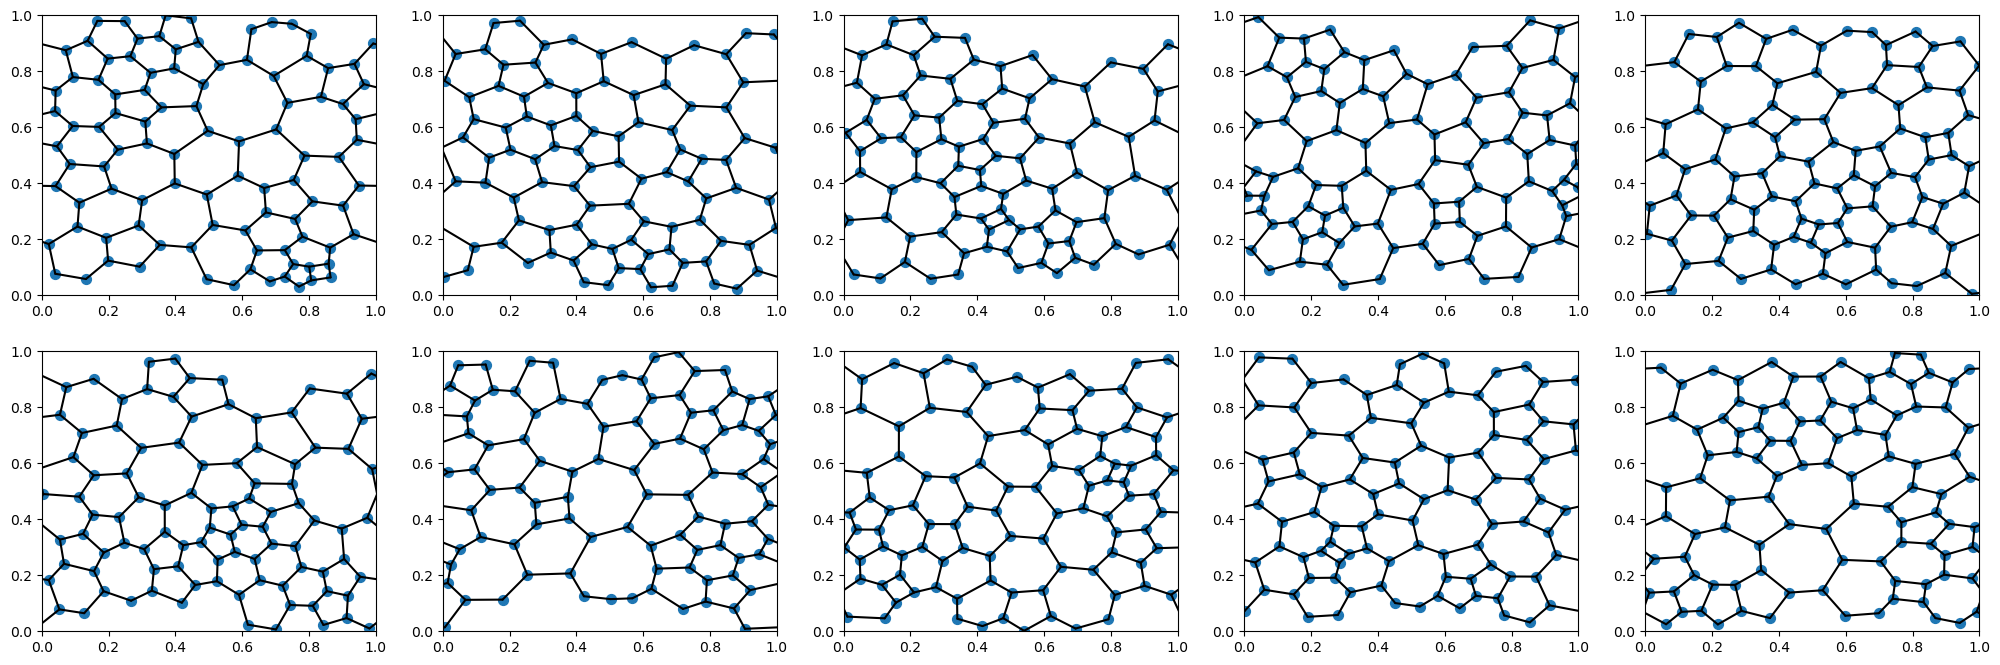

In [41]:
fig, axs = plt.subplots(2, seeds//2, figsize=(5*seeds//2, 8))
for j in range(seeds):
    ax = axs.flatten()[j]
    pl.plot_edges(lattices[j], ax=ax)
    im = ax.scatter(
        lattices[j].vertices.positions[:, 0],
        lattices[j].vertices.positions[:, 1],
        cmap="gist_stern_r",
        s=50,
        vmin=0,
        vmax=2,
    )

In [50]:
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

conds = []; ms = []; cond_spins = []; doss = [];

for j in range(seeds):

    lattice = lattices[j]

    initial_m = np.full(lattice.n_vertices, 1)  # initial magnetization
    initial_parameters = {"t1": t1,"t2": t2,"J": J,"filling": filling,"initial_m": initial_m,"theta_offset": theta_offset}
    m_values = hartree_fock(lattice, initial_parameters, n_fock_steps,tol_mdiff=1e-2)


    hamiltonian = alt_hamiltonian(
        lattice,
        t1,
        t2,
        J,
        m_values[-1],
    )

    energies, states = la.eigh(hamiltonian)
    fermi_energy = energies[int(filling*len(energies))] #better algorithm to get Fermi energy

    n_orbitals = 4
    lead_onsite = np.eye(n_orbitals)
    lead_coupling = np.eye(n_orbitals)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice, k_lattice, k_system, contact_vertices, lead_onsite, lead_coupling, np.diag([-1,-1,1,1])
    )

    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f,energy=fermi_energy)
    g = np.array([[smatrix.transmission((1,j),(0,i)) for j in range(2)] for i in range(2)])
    
    broadening = 0.05
    dos = np.sum(broadening/((energies-fermi_energy)**2 + broadening**2))/lattice.n_vertices
    
    conds.append(g[0,0]+g[1,1])
    cond_spins.append(g[0,0]-g[1,1])
    ms.append(m_values[-1])
    doss.append(dos)

conds = np.array(conds)
cond_spins = np.array(cond_spins)
#ms = np.array(ms)
doss = np.array(doss)

Avg:0.38, diff: 0.008239:  83%|████████▎ | 83/100 [00:03<00:00, 23.43it/s]


0.3621454118554025 0.09188989808742569


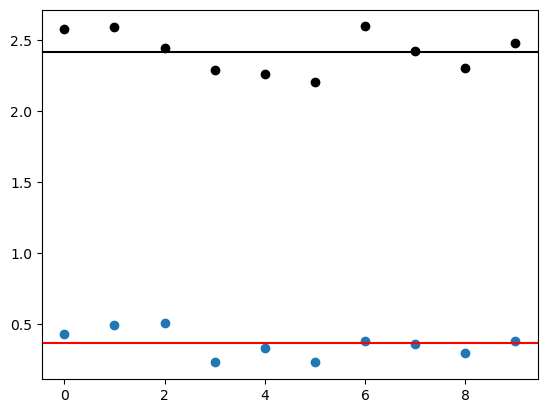

In [52]:
mavgs = [np.mean(x) for x in ms]

plt.plot(mavgs, "o")
plt.axhline(np.mean(mavgs), color="red")

plt.plot(doss, "ko")
plt.axhline(doss.mean(), color="k")

print(np.mean(mavgs), np.std(mavgs))

conductance mean + std,:  3.0897696958938266 0.7803384632184965
spin conductance mean + std,:  0.10772763909692044 0.28364149738651623


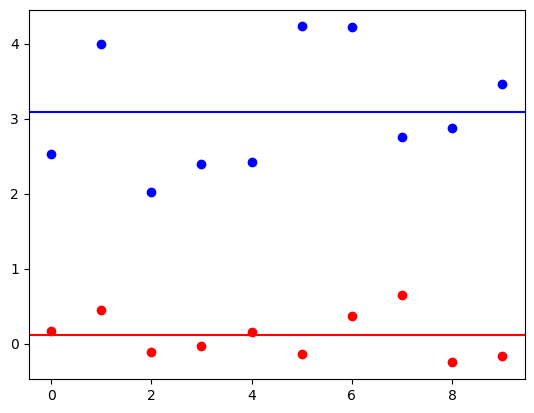

In [53]:
plt.plot(conds, "bo",label='conductance')
plt.plot(cond_spins, "ro",label='conductance')
plt.axhline(conds.mean(), color="b")
plt.axhline(cond_spins.mean(), color="r")

print('conductance mean + std,: ',conds.mean(), conds.std())
print('spin conductance mean + std,: ',cond_spins.mean(), cond_spins.std())